# Coursework Assessment: Question 2
---

## Q2(a) — Chebyshev Collocation Method for a Boundary Value Problem 
Solve the BVP

$t^2 x''(t)+t x'(t)+(t^2-1)x(t)=0,\qquad t\in[-8,8],$

with boundary conditions

$x(-8)=-1,\qquad x(8)=1.$

The exact solution (given) is

$x_{\text{exact}}(t)=\frac{J_1(t)}{J_1(8)}.$


### Step 1 — Map the interval to $[-1,1]$
Chebyshev collocation is naturally formulated on $[-1,1]$. Use the linear map

$t=8s,\qquad s\in[-1,1],\qquad y(s)=x(8s).$

Then

$x_t=\frac{1}{8}y_s,\qquad x_{tt}=\frac{1}{64}y_{ss}.$

Substitute into the ODE:

$(8s)^2\frac{1}{64}y_{ss}+(8s)\frac{1}{8}y_s+\big((8s)^2-1\big)y=0,$

which simplifies to

$s^2 y''(s)+s y'(s)+(64s^2-1)\,y(s)=0,\qquad s\in[-1,1].$

Boundary conditions become

$y(-1)=-1,\qquad y(1)=1.$


### Step 2 — Choose Chebyshev collocation points
Use \(n\) CGL points (including endpoints):

$s_j=\cos\left(\frac{\pi j}{n-1}\right),\quad j=0,1,\dots,n-1.$

These points cluster near the endpoints and include $s=\pm1$, which makes it easy to impose Dirichlet boundary conditions directly.


### Step 3 — Use Chebyshev differentiation matrices
Let

$\mathbf{y}=\big[y(s_0),y(s_1),\dots,y(s_{n-1})\big]^T.$

Construct the Chebyshev first-derivative matrix \(D\) on the CGL nodes so that

$\mathbf{y}'\approx D\mathbf{y}.$

Then approximate the second derivative using

$\mathbf{y}''\approx D^2\mathbf{y},\qquad D^2=D\,D.$


### Step 4 — Collocate the ODE to form a linear system
Enforce the mapped ODE at the collocation points:

$s^2 y'' + s y' + (64s^2-1)y=0.$

Replace \(y'\) and \(y''\) by matrix approximations to obtain a discrete system

$A\mathbf{y}=\mathbf{0},$

where

$A=\operatorname{diag}(s^2)D^2+\operatorname{diag}(s)D+\operatorname{diag}(64s^2-1).$


### Step 5 — Impose boundary conditions by row replacement
Because $s_0=1$ and $s_{n-1}=-1$ are included in the grid, impose Dirichlet conditions by overwriting the endpoint equations:

- Enforce $y(1)=1$: replace the row of the system corresponding to $s=1$ with

  $y(s_0)=1.$

- Enforce $y(-1)=-1$: replace the row corresponding to $s=-1$ with

  $y(s_{n-1})=-1.$

After this replacement, solve the linear system for $\mathbf{y}$.  
Finally, mapping back to the original variable:

$t_j=8s_j,\qquad x(t_j)=y(s_j).$


### Step 6 — Measure the error and identify when accuracy stops improving
Compare the numerical solution with the exact solution

$x_{\text{exact}}(t)=\frac{J_1(t)}{J_1(8)}.$

A typical choice of error is the max-norm on $[-8,8]$:

$E_n=\max_{t\in[-8,8]}\big|x_n(t)-x_{\text{exact}}(t)\big|.$

In practice, evaluate $x_n(t)$ on a dense set of points using stable interpolation from the Chebyshev grid (e.g., barycentric interpolation), then compute the maximum difference.

As $n$ increases, Chebyshev collocation exhibits **spectral convergence** (very rapid error decay) until the error reaches a **machine-precision plateau**. Beyond that plateau, increasing $n$ does not improve accuracy due to round-off error and increasing conditioning of the discretized operator.


### Final Answer
- **Exact solution**:

$\boxed{x(t)=\frac{J_1(t)}{J_1(8)}.}$

- **Chebyshev collocation procedure**: map to $[-1,1]$, choose CGL points, build $D$ and $D^2$, assemble

$A=\operatorname{diag}(s^2)D^2+\operatorname{diag}(s)D+\operatorname{diag}(64s^2-1),$

impose $y(1)=1$, $y(-1)=-1$ by row replacement, solve for $\mathbf{y}$, and map back to obtain $x(t)$ on $[-8,8]$.

Best (min) error occurs at n = 29, max error ≈ 2.253e-13
Plateau begins around n ≈ 29  (within 1.05× of best error)


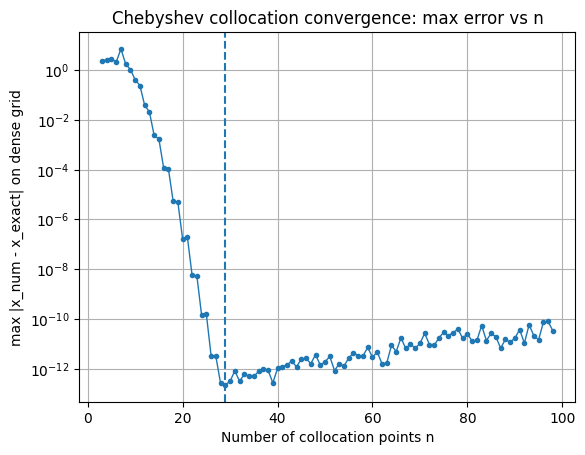

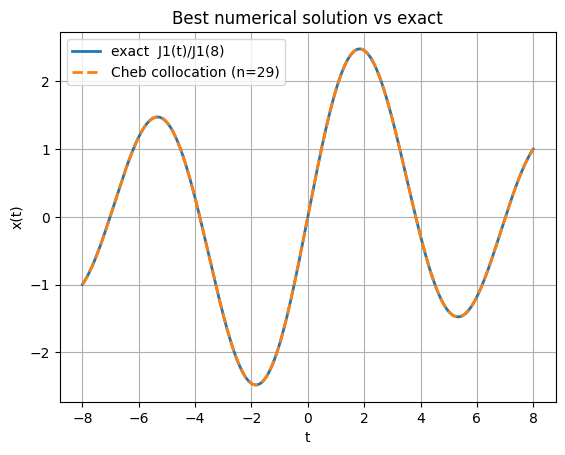

In [ ]:
# ==================== Q2(a) ====================
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv
from scipy.interpolate import BarycentricInterpolator


T_MIN = -8.0
T_MAX = 8.0
J1_AT_8 = jv(1, 8.0)


def _sort_nodes(t_nodes, x_nodes):
    """
    Sort collocation nodes for stable interpolation usage.
    """
    idx = np.argsort(t_nodes)
    return t_nodes[idx], x_nodes[idx]


def cheb_D1(N: int):
    """
    Chebyshev first-derivative matrix on Chebyshev–Gauss–Lobatto nodes.
    Returns:
      x: nodes in [-1,1] (length N)
      D: NxN first-derivative matrix
    """
    if N < 2:
        raise ValueError("N must be >= 2")

    k = np.arange(N)
    x = np.cos(np.pi * k / (N - 1))  # CGL nodes, x[0]=1, x[-1]=-1

    c = np.ones(N)
    c[0] = 2.0
    c[-1] = 2.0
    c = c * ((-1.0) ** k)

    # Same formula as before, but with broadcasting instead of tiling.
    dX = x[:, None] - x[None, :]
    D = np.outer(c, 1.0 / c) / (dX + np.eye(N))  # off-diagonal correct, diagonal temp
    D = D - np.diag(np.sum(D, axis=1))           # enforce row sums = 0 -> correct diagonal

    return x, D


def solve_bvp_cheb(n: int):
    """
    Solve:
      s^2 y'' + s y' + (64 s^2 - 1) y = 0,  s in [-1,1]
      y(-1) = -1, y(1) = 1
    via Chebyshev collocation with n nodes (CGL).
    """
    s, D = cheb_D1(n)
    D2 = D @ D

    # Build operator matrix A
    A = np.diag(s**2) @ D2 + np.diag(s) @ D + np.diag(64.0 * s**2 - 1.0)
    b = np.zeros(n)

    # Enforce boundary conditions by replacing rows:
    # s[0]=+1, s[-1]=-1.
    A[0, :] = 0.0
    A[0, 0] = 1.0
    b[0] = 1.0      # y(1)=1  -> x(8)=1

    A[-1, :] = 0.0
    A[-1, -1] = 1.0
    b[-1] = -1.0    # y(-1)=-1 -> x(-8)=-1

    y = np.linalg.solve(A, b)

    # Map back to t = 8s, x(t)=y(s)
    t = 8.0 * s
    x = y.copy()
    return t, x, s


def x_exact(t):
    return jv(1, t) / J1_AT_8


def max_error_on_dense_grid(t_nodes, x_nodes, m=4001):
    """
    Use barycentric interpolation from Chebyshev nodes to a dense uniform grid in [-8,8],
    then compute max error vs exact.
    """
    # BarycentricInterpolator expects x sorted increasing for best behavior.
    t_sorted, x_sorted = _sort_nodes(t_nodes, x_nodes)
    interp = BarycentricInterpolator(t_sorted, x_sorted)

    t_dense = np.linspace(T_MIN, T_MAX, m)
    x_num = interp(t_dense)
    err = np.max(np.abs(x_num - x_exact(t_dense)))
    return err


def main():
    # Scan n values
    n_list = list(range(3, 99)) 
    errs = np.empty(len(n_list), dtype=float)

    for i, n in enumerate(n_list):
        t_nodes, x_nodes, _ = solve_bvp_cheb(n)
        errs[i] = max_error_on_dense_grid(t_nodes, x_nodes, m=5001)

    # Find best n (minimum error)
    i_best = int(np.argmin(errs))
    n_best = n_list[i_best]
    err_best = float(errs[i_best])

    # Find "no longer improves" point:
    # A practical definition: first n after which improvement is < 5% of best (or within factor 1.05).
    tol_factor = 1.05
    plateau_candidates = np.where(errs <= tol_factor * err_best)[0]
    n_plateau = n_list[int(plateau_candidates[0])] if plateau_candidates.size else n_best

    print(f"Best (min) error occurs at n = {n_best}, max error ≈ {err_best:.3e}")
    print(f"Plateau begins around n ≈ {n_plateau}  (within {tol_factor:.2f}× of best error)")

    # Plotting
    plt.figure()
    plt.semilogy(n_list, errs, marker='o', markersize=3, linewidth=1)
    plt.axvline(n_best, linestyle='--')
    plt.title("Chebyshev collocation convergence: max error vs n")
    plt.xlabel("Number of collocation points n")
    plt.ylabel("max |x_num - x_exact| on dense grid")
    plt.grid(True, which='both')

    # Plot Best Numercial Solution vs Exact
    t_nodes, x_nodes, _ = solve_bvp_cheb(n_best)
    t_sorted, x_sorted = _sort_nodes(t_nodes, x_nodes)
    interp = BarycentricInterpolator(t_sorted, x_sorted)

    t_dense = np.linspace(T_MIN, T_MAX, 2001)
    x_num = interp(t_dense)
    x_ex = x_exact(t_dense)

    plt.figure()
    plt.plot(t_dense, x_ex, linewidth=2, label="exact  J1(t)/J1(8)")
    plt.plot(t_dense, x_num, linestyle='--', linewidth=2, label=f"Cheb collocation (n={n_best})")
    plt.title("Best numerical solution vs exact")
    plt.xlabel("t")
    plt.ylabel("x(t)")
    plt.grid(True)
    plt.legend()

    plt.show()


if __name__ == "__main__":
    main()

In [ ]:
# ==================== Q2(b) ====================
import mpmath as mp


def choose_best_n(n_min=3, n_max=98):
    n_values = list(range(n_min, n_max + 1))
    errors = []
    for n in n_values:
        t_nodes, x_nodes, _ = solve_bvp_cheb(n)
        errors.append(max_error_on_dense_grid(t_nodes, x_nodes, m=5001))
    errors = np.array(errors)
    i_best = int(np.argmin(errors))
    return n_values[i_best], np.array(n_values), errors


def cheb_coeffs_on_minus8_8(t_nodes, x_nodes):
    t_sorted, x_sorted = _sort_nodes(t_nodes, x_nodes)
    s_sorted = t_sorted / 8.0
    coeff = np.polynomial.chebyshev.chebfit(s_sorted, x_sorted, deg=len(s_sorted) - 1)
    return coeff, t_sorted, x_sorted


def cheb_eval_mpmath(t, coeffs_mp, a=mp.mpf("-8.0"), b=mp.mpf("8.0")):
    # Clenshaw recurrence, works for mp.mpf and interval type mp.iv.mpf.
    s = (2 * t - (a + b)) / (b - a)
    zero = t - t
    b1 = zero
    b2 = zero
    for ck in reversed(coeffs_mp[1:]):
        b0 = 2 * s * b1 - b2 + ck
        b2 = b1
        b1 = b0
    return s * b1 - b2 + coeffs_mp[0]


def build_mpmath_interpolator(coeff):
    coeffs_mp = [mp.mpf(str(c)) for c in coeff]

    def f_np(t):
        t_arr = np.asarray(t)
        return np.polynomial.chebyshev.chebval(t_arr / 8.0, coeff)

    def f_mp(t):
        return cheb_eval_mpmath(mp.mpf(t), coeffs_mp)

    def f_iv(interval_t):
        return cheb_eval_mpmath(interval_t, coeffs_mp)

    return coeffs_mp, f_np, f_mp, f_iv


def find_brackets_float(f_np, a=-8.0, b=8.0, samples=50001, near_zero=1e-9):
    t = np.linspace(a, b, samples)
    y = f_np(t)
    h = t[1] - t[0]
    brackets = []

    for i in range(samples - 1):
        y0 = y[i]
        y1 = y[i + 1]
        if np.isnan(y0) or np.isnan(y1):
            continue

        if y0 == 0.0:
            brackets.append([max(a, t[i] - h), min(b, t[i] + h)])
        elif y0 * y1 < 0.0:
            brackets.append([t[i], t[i + 1]])
        elif abs(y0) < near_zero:
            brackets.append([max(a, t[i] - h), min(b, t[i] + h)])

    brackets.sort(key=lambda p: p[0])
    merged = []
    for L, U in brackets:
        if not merged or L > merged[-1][1]:
            merged.append([L, U])
        else:
            merged[-1][1] = max(merged[-1][1], U)
    return merged


def contains_zero(interval_y):
    return interval_y.a <= 0 <= interval_y.b


def validated_bisection_on_bracket(f_mp, f_iv, a, b, tol=mp.mpf("2.0") ** (-45), max_iter=240):
    a = mp.mpf(str(a))
    b = mp.mpf(str(b))
    fa = f_mp(a)
    fb = f_mp(b)

    if fa == 0:
        return mp.iv.mpf([a, a])
    if fb == 0:
        return mp.iv.mpf([b, b])

    if fa * fb > 0:
        pad = mp.mpf("1e-6")
        a = max(mp.mpf("-8.0"), a - pad)
        b = min(mp.mpf("8.0"), b + pad)
        fa = f_mp(a)
        fb = f_mp(b)

    if fa * fb > 0:
        return mp.iv.mpf([a, b])

    for _ in range(max_iter):
        interval_x = mp.iv.mpf([a, b])
        if not contains_zero(f_iv(interval_x)):
            return interval_x
        if (b - a) <= tol:
            return interval_x

        m = (a + b) / 2
        fm = f_mp(m)

        if fm == 0:
            return mp.iv.mpf([m, m])
        if fa * fm <= 0:
            b = m
            fb = fm
        else:
            a = m
            fa = fm

    return mp.iv.mpf([a, b])


def merge_connected_intervals(intervals, gap_tol=mp.mpf("1e-30")):
    if not intervals:
        return []
    intervals = sorted(intervals, key=lambda I: (I.a, I.b))
    merged = [intervals[0]]
    for I in intervals[1:]:
        last = merged[-1]
        if I.a <= last.b + gap_tol:
            merged[-1] = mp.iv.mpf([min(last.a, I.a), max(last.b, I.b)])
        else:
            merged.append(I)
    return merged


mp.mp.dps = 80

# Reuse Q2(a) solver and pick the best n from the same error criterion.
n_best, n_values, errors = choose_best_n(3, 98)
t_nodes, x_nodes, _ = solve_bvp_cheb(n_best)
coeff, t_sorted, x_sorted = cheb_coeffs_on_minus8_8(t_nodes, x_nodes)
coeffs_mp, f_np, f_mp, f_iv = build_mpmath_interpolator(coeff)

node_fit = np.polynomial.chebyshev.chebval(t_sorted / 8.0, coeff)
print(f"Q2(b): use n = {n_best} from Q2(a) (min dense-grid error ~ {errors.min():.3e})")
print(f"Chebyshev interpolation error at collocation nodes: {np.max(np.abs(node_fit - x_sorted)):.3e}")

# Root isolation + validated interval bisection.
brackets = find_brackets_float(f_np, a=-8.0, b=8.0, samples=50001, near_zero=1e-9)
root_boxes_raw = [
    validated_bisection_on_bracket(f_mp, f_iv, L, U, tol=mp.mpf("2.0") ** (-45), max_iter=240)
    for (L, U) in brackets
]
root_boxes = merge_connected_intervals(root_boxes_raw)

print("\nIntervals containing roots (after merging connected intervals):")
for i, I in enumerate(root_boxes, start=1):
    a_i = float(I.a)
    b_i = float(I.b)
    w_i = float(I.delta)
    mid_i = 0.5 * (a_i + b_i)
    print(f"{i}: [{a_i:.16f}, {b_i:.16f}]   width = {w_i:.3e}, midpoint = {mid_i:.16f}")

# Widths of validated intervals and an equivalent bit-loss estimate.
if len(root_boxes) > 0:
    widths = np.array([float(I.delta) for I in root_boxes])
    bits_kept_from_width = -np.log2(widths)
    bits_lost_from_width = np.maximum(0.0, 53.0 - bits_kept_from_width)
    print("\nBinary-bit loss estimate from validated root-interval widths:")
    print(f"mean bits lost ~ {bits_lost_from_width.mean():.2f}, worst-case bits lost ~ {bits_lost_from_width.max():.2f}")

# Estimate interpolation-induced bit loss against the known exact solution.
t_dense = np.linspace(-8.0, 8.0, 12001)
x_interp = f_np(t_dense)
x_ex = x_exact(t_dense)
interp_max_err = float(np.max(np.abs(x_interp - x_ex)))
bits_kept_interp = -np.log2(interp_max_err)
bits_lost_interp = max(0.0, 53.0 - bits_kept_interp)

print("\nInterpolator accuracy on dense grid:")
print(f"max |p_n(t) - x_exact(t)| ~ {interp_max_err:.3e}")
print(f"estimated accurate bits ~ {bits_kept_interp:.2f}")
print(f"estimated bits lost from double precision (53 bits) ~ {bits_lost_interp:.2f}")

# Optional comparison to exact J1 roots in [-8, 8].
r1 = float(mp.besseljzero(1, 1))
r2 = float(mp.besseljzero(1, 2))
exact_roots = np.array([-r2, -r1, 0.0, r1, r2])
approx_roots = np.array(sorted([0.5 * (float(I.a) + float(I.b)) for I in root_boxes]))

if approx_roots.size == exact_roots.size:
    root_abs_err = np.abs(approx_roots - exact_roots)
    print("\nMidpoint root errors vs exact J1 roots:")
    for k, (ra, re, eabs) in enumerate(zip(approx_roots, exact_roots, root_abs_err), start=1):
        print(f"root {k}: approx = {ra:.16f}, exact = {re:.16f}, |error| = {eabs:.3e}")


